In [1]:
import sys 
import os
sys.path.append(os.path.abspath("../")) 

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from utils.likelihood import *
from utils.formate_matrix_toMLData import *
from models.model_0929 import *
# import matplotlib.pyplot as plt
import japanize_matplotlib
# plt.rcParams["font.family"]="Open Sans"
# plt.rcParams["font.size"] = 22
np.set_printoptions(suppress=True)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
plt.rcParams["font.size"] = 14
# font_path = "/Users/yamashitanatsuki/Library/Fonts/OpenSans-VariableFont_wdth,wght.ttf"

# # フォントを Matplotlib に登録
# fm.fontManager.addfont(font_path)

# # フォント名取得（登録後の認識名を確認）
# font_prop = fm.FontProperties(fname=font_path)
# font_name = font_prop.get_name()
# print("Registered Font Name:", font_name)

# # rcParams に反映
# mpl.rcParams['font.family'] = font_name
# mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['ps.fonttype'] = 42
# plt.plot([1,2,3])
# plt.title("Using Open Sans Variable Font")
# plt.show()

In [4]:
device = torch.device("cpu")
model = DeepSets_varSets_forDiagnel(device=device).to(device)
model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_0929.pth", map_location=device))
model.eval()

/tmp/ipykernel_356696/3267676366.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_0929.pth", m

DeepSets_varSets_forDiagnel(
  (embedding): Embedding(5, 16, padding_idx=0)
  (fc1): Linear(in_features=33, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.2, inplace=False)
  (att_fc): Linear(in_features=512, out_features=512, bias=True)
  (att_score): Linear(in_features=512, out_features=1, bias=True)
  (out_fc1): Linear(in_features=512, out_features=128, bias=True)
  (out_ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (out_fc2): Linear(in_features=128, out_features=64, bias=True)
  (out_ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (out_fc3): Linear(in_features=64, out_features=3, bias=True)
)

In [5]:

if torch.cuda.is_available():
    device = torch.device("cuda")
# elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
#     device = torch.device("mps")
else:
    device = torch.device("cpu")

model = DeepSets_varSets_forDiagnel(device=device)
model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_0929.pth", map_location=device))
model.eval()

/tmp/ipykernel_356696/4028822419.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../model_weights/mixed_distribution/mixed_0929.pth", m

DeepSets_varSets_forDiagnel(
  (embedding): Embedding(5, 16, padding_idx=0)
  (fc1): Linear(in_features=33, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=512, bias=True)
  (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.2, inplace=False)
  (att_fc): Linear(in_features=512, out_features=512, bias=True)
  (att_score): Linear(in_features=512, out_features=1, bias=True)
  (out_fc1): Linear(in_features=512, out_features=128, bias=True)
  (out_ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (out_fc2): Linear(in_features=128, out_features=64, bias=True)
  (out_ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (out_fc3): Linear(in_features=64, out_features=3, bias=True)
)

In [6]:
formater = formate_dataMatrix()

# 読み込む対象の拡張子（例: .csv のみに限定）
VALID_EXTENSIONS = (".csv", ".txt")
IGNORED_PREFIXES = ("._", ".DS_Store", "Thumbs.db")

# ファイルを処理する関数
def process_file(file_path, states_sets, delt_sets, true_sets,targets_sets,ll_use):
    try:
        # print("Processing:", file_path)
        with open(file_path, 'rb') as f:
            all_matrix = np.loadtxt(f, delimiter=",")

        tm = matrix_trimer(all_matrix)
        true_trm = tm.trim_transitionRateMatrix(start = 0, end = 4)
        true_vec = np.array(formater.GetOutputVector_byDiagonal(true_trm))
        data = []
        if ll_use:
            
            ll_trm = tm.trim_transitionRateMatrix(start = 4, end = 8)
            ll_vec = np.array(formater.GetOutputVector_byDiagonal(ll_trm))
            data = tm.trim_data(start = 8)
        else:
            data = tm.trim_data(start = 4)
            ll_vec = np.array([0,0,0])
            
        # print(data)
        # state: shape (2, num_samples_i)
        state = np.stack([data[:, 0], data[:, 1]], axis=0)
        states_sets.append(state)
        delt_sets.append(data[:, 2])
        true_sets.append(true_vec)
        targets_sets.append(ll_vec)

    except Exception as e:
        print(f"❌ Skipping file: {file_path} (Reason: {e})")

# ディレクトリ内のファイルを一括処理
def process_all_files_in_directory(directory, func, states_sets, delt_sets, true_sets,targets_sets,ll_use = True):
    for filename in os.listdir(directory):
        if filename.startswith(IGNORED_PREFIXES):
            continue
        if not filename.endswith(VALID_EXTENSIONS):
            continue

        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path):
            func(file_path,states_sets, delt_sets, true_sets,targets_sets,ll_use)



In [7]:
class all_lifespan_loss(nn.Module):
    def forward(self, outputs, targets):
        
        y_pred_inverse = 1.0 / (outputs)
        y_true_inverse = 1.0 / (targets)

        # 逆数の差の絶対値
        loss_tensor = torch.abs(y_pred_inverse - y_true_inverse)[0]
        return loss_tensor, y_true_inverse[0], y_pred_inverse

criterion = all_lifespan_loss()

def make_test_df(
    model,
    criterion,
    test_states,
    test_del_t,
    test_targets,
    collate_fn,
    varSets_Datasets,
    device,
    batch_size=1,
):
    test_dataset = varSets_Datasets(test_states, test_del_t, test_targets)
    use_cuda = torch.cuda.is_available()

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        pin_memory=use_cuda,
    )

    d_idxes = []
    param_id = []
    loss_list = []
    outs_lifespan = []
    true_lifespan = []
    d_lengths = []

    model.eval()
    for idx, (states, delta_t, targets, lengths) in enumerate(test_dataloader):
        with torch.no_grad():
            states = states.to(device, non_blocking=True).long()
            delta_t = delta_t.to(device, non_blocking=True).float()
            targets = targets.to(device, non_blocking=True).float()
            lengths = lengths.to(device, non_blocking=True).long()

            outputs = model(states, delta_t, lengths)[0]
            loss_tensor, true_expect, pred_expect = criterion(outputs, targets)

            true_expect_cpu = true_expect.detach().cpu()
            pred_expect_cpu = pred_expect.detach().cpu()
            batch_loss = torch.abs(true_expect_cpu - pred_expect_cpu)

            true_lifespan.extend(true_expect_cpu.tolist())
            outs_lifespan.extend(pred_expect_cpu.tolist())
            loss_list.extend(batch_loss.tolist())

            # 元コードの挙動を維持（各バッチで3回 index/param を追加）
            for i in range(3):
                param_id.append(i + 1)
                d_idxes.append(idx)
                d_lengths.extend(lengths.detach().cpu().tolist())

    df = pd.DataFrame(
        {
            "index": d_idxes,
            "paramerter": param_id,  # 元の列名を維持（typoも含めて）
            "true": true_lifespan,
            "pred": outs_lifespan,
            "loss": loss_list,
            "n": d_lengths,
        }
    )
    return df


def get_target_val(df: pd.DataFrame):
    s = df["loss"].dropna().sort_values()
    n = len(s)

    ps = [0.90, 0.95, 0.99]
    idx = [int(np.ceil(p*n) - 1) for p in ps]  # 0-based index
    vals = s.iloc[idx]

    result = dict(zip(["p90", "p95", "p99"], vals.to_list()))
    result.update({
        "median": float(df["loss"].median()),
        "mean": float(df["loss"].mean()),
        "max": float(df["loss"].max()),
    })
    return result



In [8]:

base_dir = "/mnt/ssd/datas/real_data/"
data_dict = {
    "swerepipe":[1085,2171,3257],
    "BCI": [2336, 4672, 7008],
    "shoban":[1085,2171, 3257],
    "pavement":[572, 1144, 1716]
}


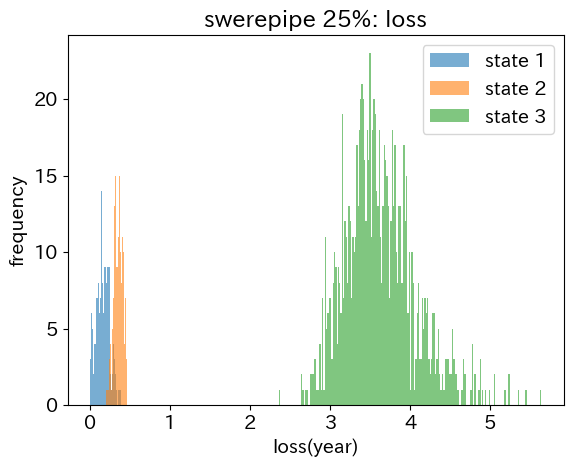

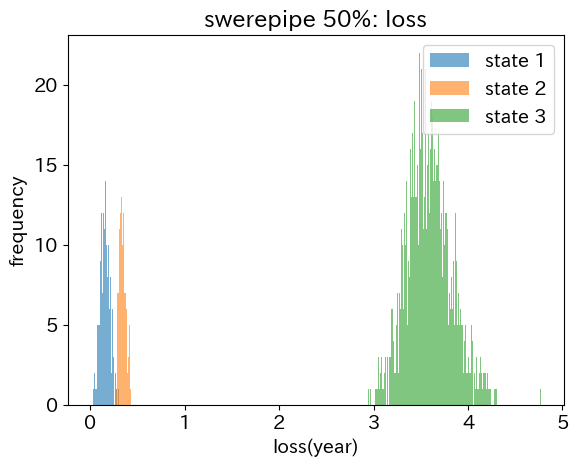

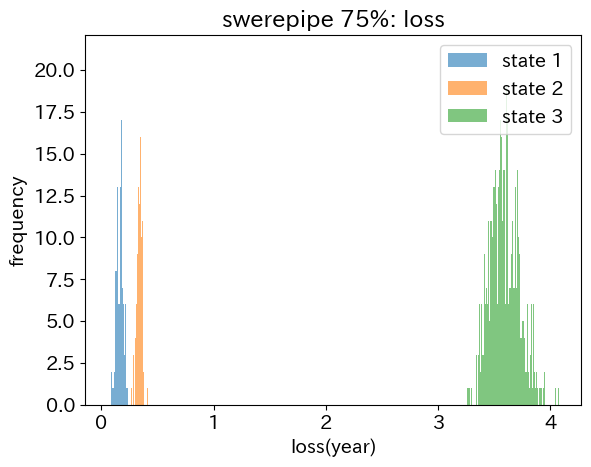

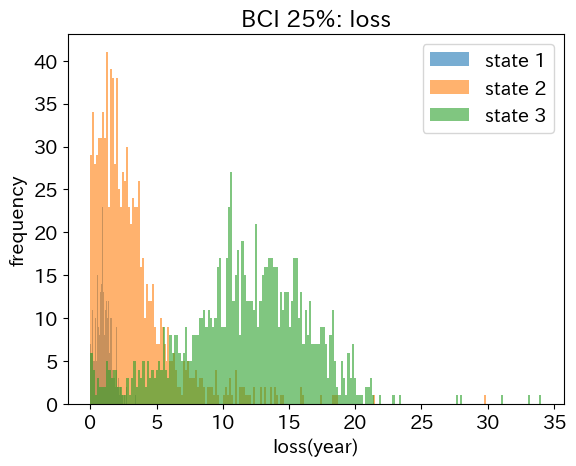

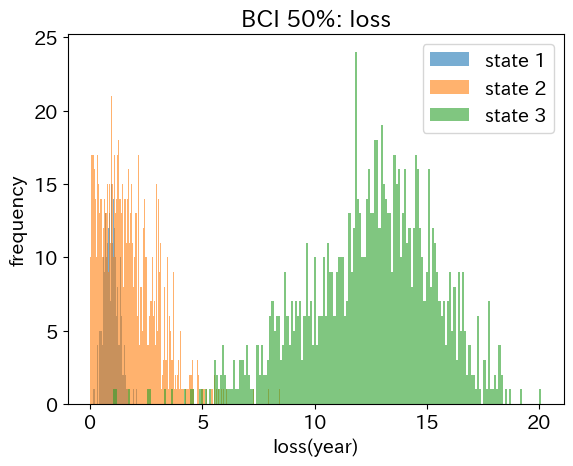

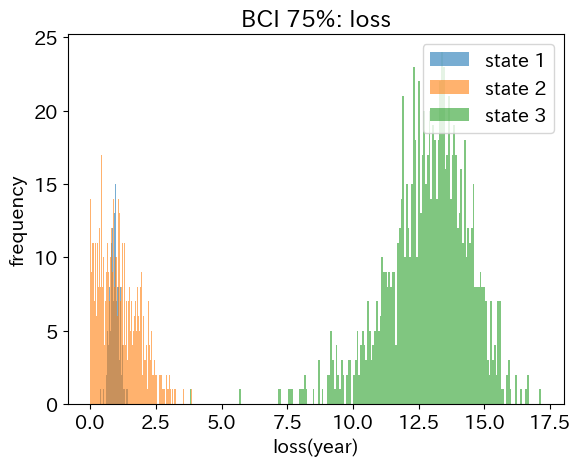

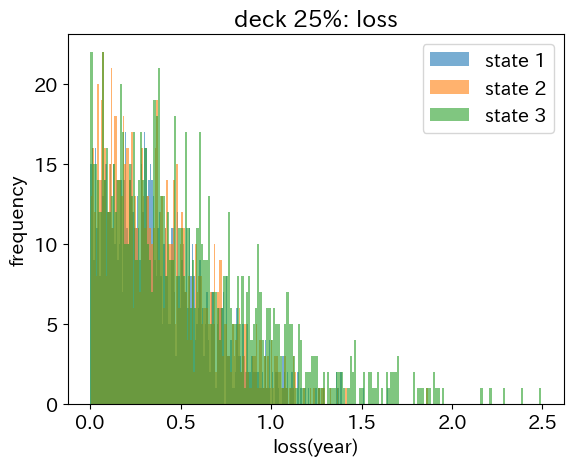

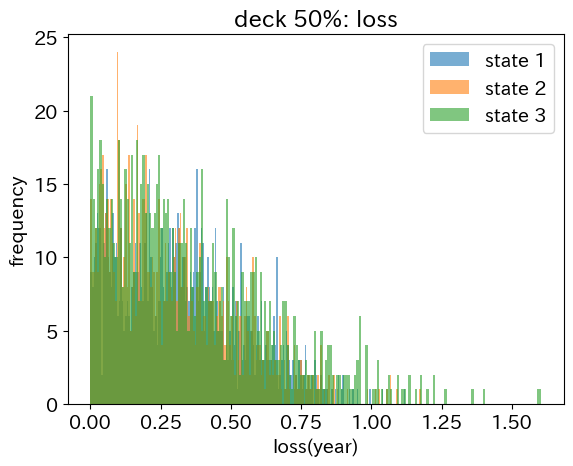

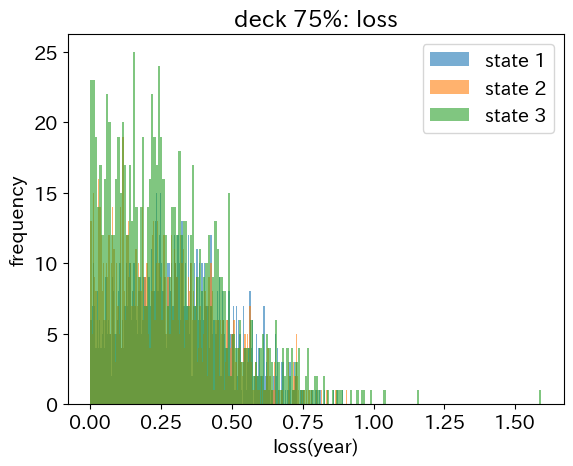

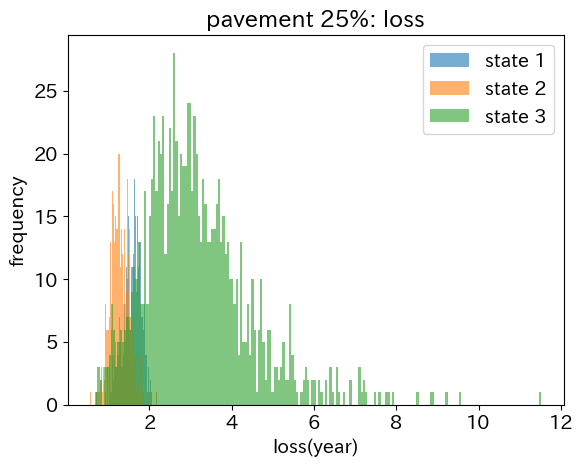

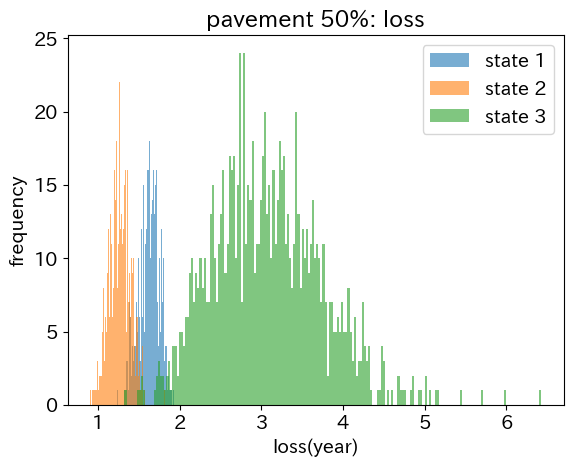

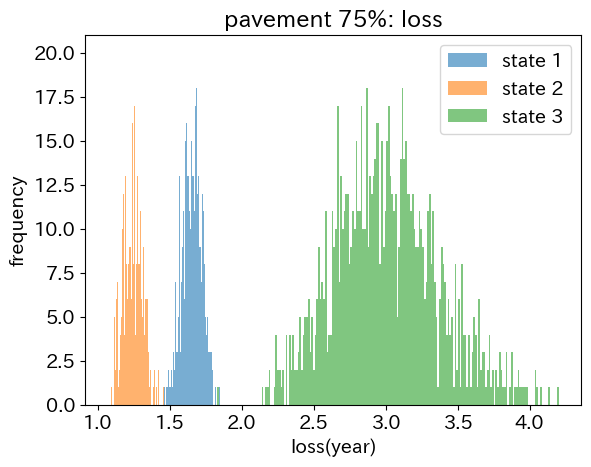

In [15]:
rows = []
percentiles = ["p90", "p95", "p99","median", "mean", "max"]
for key in data_dict.keys():
    
    for idx, n in enumerate(data_dict[key]):
        test_states = []
        test_del_t = []
        test_targets = []
        dummy = []
        data_dir = base_dir + key + "/samples_"+str(n)
        process_all_files_in_directory(data_dir,process_file, test_states, test_del_t,test_targets,dummy,False)
        r = make_test_df(model,criterion, test_states, test_del_t, test_targets,collate_fn, varSets_Datasets,device)
        
        plt.title(str(key)+f" {(idx+1)*25}%: loss")
        plt.xlabel("loss(year)")
        plt.ylabel("frequency")
        
        if str(key)=="shoban":
            plt.title(f"deck {(idx+1)*25}%: loss")
        for state in range(3):
            r_state = r[r["paramerter"]==state+1]
            plt.hist(r_state["loss"],alpha=0.6,bins=200, label=f"state {state+1}")
        plt.legend(loc='upper right')
        plt.savefig(f"{key}_{(idx+1)*25}_loss_histogram.png")
        plt.show()
        # for i in range(3):
        #     plt.hist(r["loss"][i],alpha=0.6,bins = 200)
        # plt.show()
        # for i in range(3):
        #     d = r[r["paramerter"]==i+1]
        #     r_d = get_target_val(d)
        #     for p in percentiles:
                # row = {
                #     "name": f"{key}",
                #     "%" : str((idx+1)*25)+"%",
                #     "samples": n,
                #     "condition_state": i+1,
                #     "metric": p,
                #     "value": r_d[p]
                # }
                # display(pd.DataFrame([row]))
                # if row["name"]=="shoban":
                #     row["name"] = "deck"
                # rows.append(row)

# df = pd.DataFrame(rows)
# pd.to_csv("eval_error.csv", index=False)
                
       
        
        
        

In [10]:
df.to_csv("eval_error.csv", index=False)

NameError: name 'df' is not defined

In [ ]:
data_name = "swerepipe"
n_samples = "3257"
# data_dir = "/media/user/TRANSCEND/datas/discrete_test_rundomN"
data_dir = f"{data_name}/samples_{n_samples}"

# 実行
process_all_files_in_directory(base_dir+data_dir,process_file, test_states, test_del_t,test_targets,dummy,False)

In [ ]:
test_dataset = varSets_Datasets(test_states, test_del_t, test_targets)
use_cuda = torch.cuda.is_available()
test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=use_cuda,
)
data_iter = iter(test_dataloader)
d_idxes = []
param_id =[]
loss_list = []
outs_lifespan = []
true_lifespan = []
d_lengths = []

for idx,(states, delta_t, targets, lengths) in enumerate(data_iter):
    with torch.no_grad():
        states = states.to(device, non_blocking=True).long()
        delta_t = delta_t.to(device, non_blocking=True).float()
        targets = targets.to(device, non_blocking=True).float()
        lengths = lengths.to(device, non_blocking=True).long()

        outputs = model(states, delta_t, lengths)[0]
        loss_tensor, true_expect, pred_expect = criterion(outputs, targets)

        true_expect_cpu = true_expect.detach().cpu()
        pred_expect_cpu = pred_expect.detach().cpu()
        batch_loss = torch.abs(true_expect_cpu - pred_expect_cpu)

        true_lifespan.extend(true_expect_cpu.tolist())
        outs_lifespan.extend(pred_expect_cpu.tolist())
        loss_list.extend(batch_loss.tolist())
        for i in range(3):
            param_id.append(i+1)
            d_idxes.append(idx)
            d_lengths.extend(lengths.tolist())

print(len(outs_lifespan))
print()    
        
df = pd.DataFrame({
        "index": d_idxes,
        "paramerter": param_id,
        "true": true_lifespan,
        "pred": outs_lifespan,
        "loss": loss_list,
        "n":d_lengths
    })
display(df)

6000



,index,paramerter,true,pred,loss,n
0,0,1,26.945120,28.602020,1.656900,1716
1,0,2,19.328369,18.249298,1.079071,1716
2,0,3,8.228066,11.162837,2.934771,1716
3,1,1,27.098675,28.866165,1.767490,1716
4,1,2,18.203621,17.082027,1.121593,1716
...,...,...,...,...,...,...
5995,1998,2,18.802486,19.142605,0.340118,3257
5996,1998,3,39.869587,43.515469,3.645882,3257
5997,1999,1,22.627201,22.798523,0.171322,3257
5998,1999,2,18.178890,18.511919,0.333029,3257


(array([  1.,  17.,  77., 181., 253., 238., 375., 671., 170.,  17.]),
 array([1.83109903, 2.06819625, 2.30529346, 2.54239068, 2.7794879 ,
        3.01658511, 3.25368233, 3.49077954, 3.72787676, 3.96497397,
        4.20207119]),
 <BarContainer object of 10 artists>)

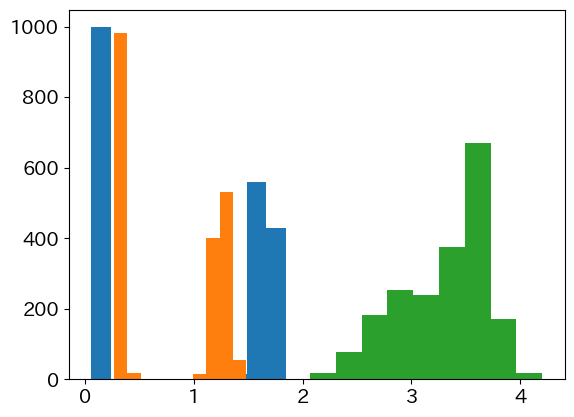

In [ ]:
df_1 = df[df["paramerter"]==1]
df_2 = df[df["paramerter"]==2]
df_3 = df[df["paramerter"]==3]
plt.hist(df_1["loss"])
plt.hist(df_2["loss"])
plt.hist(df_3["loss"])